# Package Return Tracker - ML Notebook
This notebook trains a return-likelihood model and an NLP model for return reasons.


In [1]:
import os
import pickle
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

np.random.seed(42)


In [2]:
DATA_PATH = '../data/orders.csv'
IMG_DIR = '../images'
MODEL_DIR = '../models'

os.makedirs(IMG_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

df = pd.read_csv(DATA_PATH)
print(df.head())
print('shape:', df.shape)
df.info()
print(df['returned'].value_counts())


         order_id  vendor                   item  category  price  \
0  ORD-54D5779DD4  Amazon                Sweater  clothing  41.65   
1  ORD-00B03A35A0  Newegg         Cotton T-shirt  clothing  45.78   
2  ORD-8644CE8EFB  Newegg          Running shoes     shoes  30.07   
3  ORD-146ADDD71C    Etsy          Cooking guide     books  16.82   
4  ORD-6FEB614D88    Etsy  Storage organizer set      home  82.89   

   discount_pct  multiple_sizes_ordered  order_date delivery_date  returned  
0         18.14                       1  2024-02-22    2024-03-01         0  
1         20.99                       0  2024-01-14    2024-01-21         0  
2         10.39                       0  2024-01-04    2024-01-13         0  
3          9.47                       0  2024-06-21    2024-06-23         0  
4          8.48                       0  2024-01-23    2024-02-01         0  
shape: (3000, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 10 co

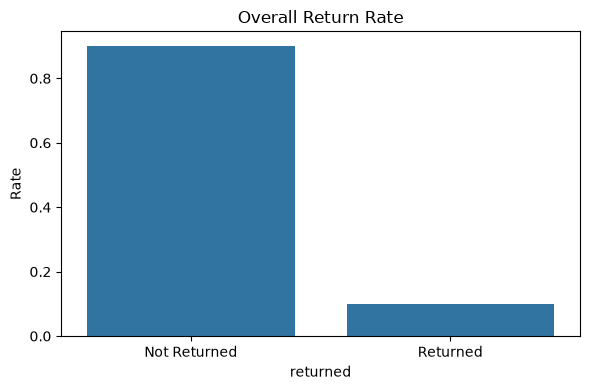

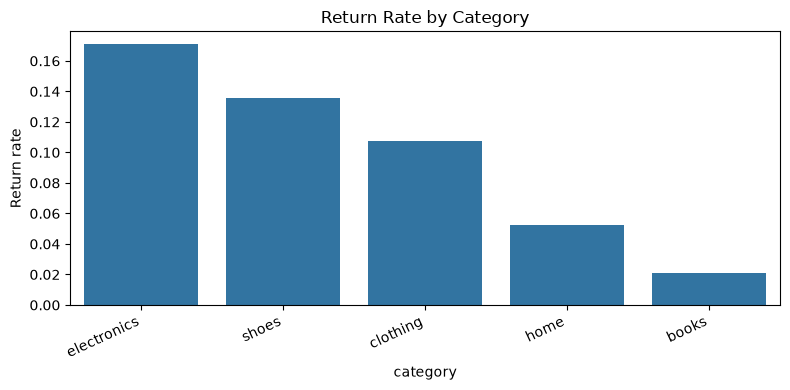

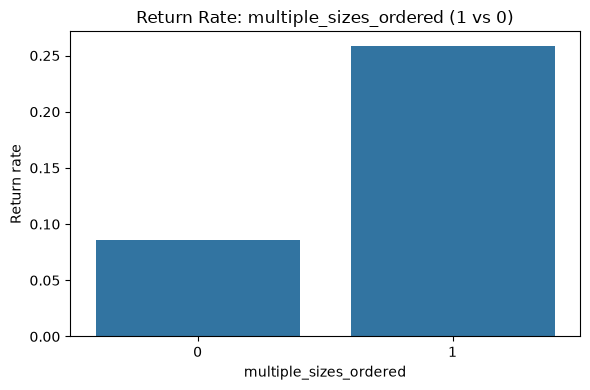

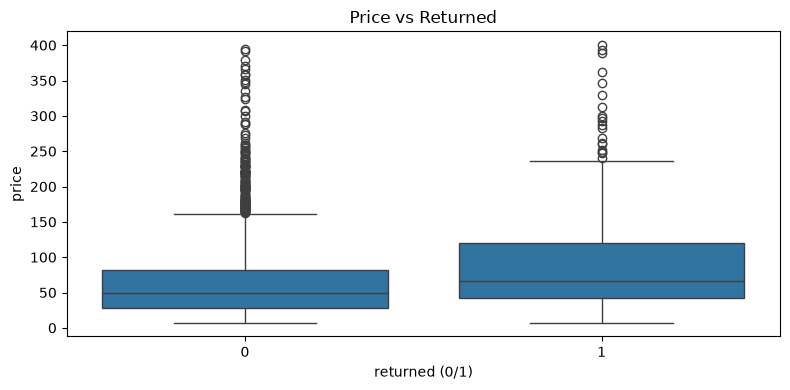

In [3]:
# Chart 1: overall return rate bar chart
return_rate = df['returned'].value_counts(normalize=True).sort_index()
plt.figure(figsize=(6,4))
sns.barplot(x=return_rate.index.map(lambda x: 'Returned' if x==1 else 'Not Returned'), y=return_rate.values)
plt.ylabel('Rate')
plt.title('Overall Return Rate')
plt.tight_layout()
p1 = os.path.join(IMG_DIR, 'overall_return_rate.png')
plt.savefig(p1, dpi=160)
plt.show()

# Chart 2: return rate by category
cat_rate = df.groupby('category')['returned'].mean().sort_values(ascending=False)
plt.figure(figsize=(8,4))
sns.barplot(x=cat_rate.index, y=cat_rate.values)
plt.ylabel('Return rate')
plt.title('Return Rate by Category')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
p2 = os.path.join(IMG_DIR, 'return_rate_by_category.png')
plt.savefig(p2, dpi=160)
plt.show()

# Chart 3: return rate by multiple_sizes_ordered
ms_rate = df.groupby('multiple_sizes_ordered')['returned'].mean().sort_index()
plt.figure(figsize=(6,4))
sns.barplot(x=ms_rate.index.map(lambda x: str(x)), y=ms_rate.values)
plt.ylabel('Return rate')
plt.title('Return Rate: multiple_sizes_ordered (1 vs 0)')
plt.tight_layout()
p3 = os.path.join(IMG_DIR, 'return_rate_multiple_sizes_ordered.png')
plt.savefig(p3, dpi=160)
plt.show()

# Chart 4: price vs returned box plot
plt.figure(figsize=(8,4))
sns.boxplot(x='returned', y='price', data=df)
plt.xlabel('returned (0/1)')
plt.title('Price vs Returned')
plt.tight_layout()
p4 = os.path.join(IMG_DIR, 'price_vs_returned_boxplot.png')
plt.savefig(p4, dpi=160)
plt.show()


**EDA insights (sample)**
1. Categories with higher average return rates tend to cluster around items that are harder to fit/verify (size variation) or have higher perceived risk (electronics).
2. Orders with `multiple_sizes_ordered=1` show a noticeably higher return rate, which is consistent with a ‘try different sizes’ shopping behavior.


In [4]:
# Preprocessing
df2 = df.dropna().copy()
# Ensure numeric types
df2['price'] = pd.to_numeric(df2['price'], errors='coerce')
df2['discount_pct'] = pd.to_numeric(df2['discount_pct'], errors='coerce')
df2 = df2.dropna()

# Fit scaler on train only
X = df2.drop(columns=['returned'])
y = df2['returned'].astype(int)

# One-hot encode categorical columns via get_dummies
cat_cols = ['category', 'vendor']
num_cols = ['price', 'discount_pct']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_dum = pd.get_dummies(X_train, columns=cat_cols, drop_first=False)
X_test_dum = pd.get_dummies(X_test, columns=cat_cols, drop_first=False)

# Align columns after get_dummies
X_test_dum = X_test_dum.reindex(columns=X_train_dum.columns, fill_value=0)

# StandardScaler on numeric columns
scaler = StandardScaler()

X_train_scaled = X_train_dum.copy()
X_test_scaled = X_test_dum.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train_dum[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test_dum[num_cols])


In [5]:
# Train/test split already done above; X and y are the features/labels
X_train_final = X_train_scaled
X_test_final = X_test_scaled


In [6]:
models = {
    'LogisticRegression': LogisticRegression(max_iter=500),
    'RandomForestClassifier': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBClassifier': XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=4,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric='logloss',
        random_state=42
    )
}

results = {}
for name, model in models.items():
    model.fit(X_train_final, y_train)
    y_pred = model.predict(X_test_final)
    # predict_proba for ROC-AUC
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test_final)[:,1]
    else:
        y_proba = None

    print('===', name, '===')
    print(classification_report(y_test, y_pred))

    auc = roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan
    results[name] = {'auc': auc}

print('AUCs:', {k: v['auc'] for k,v in results.items()})


ValueError: could not convert string to float: 'ORD-4EAFD0714F'

In [ ]:
# Evaluate best model by ROC-AUC
best_name = max(results.keys(), key=lambda k: results[k]['auc'])
best_model = models[best_name]
best_y_pred = best_model.predict(X_test_final)
best_y_proba = best_model.predict_proba(X_test_final)[:,1]
best_auc = roc_auc_score(y_test, best_y_proba)

# Confusion matrix heatmap
cm = confusion_matrix(y_test, best_y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {best_name}')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
p_cm = os.path.join(IMG_DIR, 'best_confusion_matrix.png')
plt.savefig(p_cm, dpi=160)
plt.show()

# ROC-AUC curve
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_test, best_y_proba)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'AUC={best_auc:.3f}')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve - {best_name}')
plt.legend()
plt.tight_layout()
p_roc = os.path.join(IMG_DIR, 'best_roc_curve.png')
plt.savefig(p_roc, dpi=160)
plt.show()

# Feature importance (top 10). Use model attribute when available
plt.figure(figsize=(8,4))
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
elif hasattr(best_model, 'coef_'):
    # for linear models: absolute coefficients
    importances = np.abs(best_model.coef_).ravel()
else:
    importances = np.zeros(X_train_final.shape[1])

feature_names = list(X_train_final.columns)
imp_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
imp_df = imp_df.sort_values('importance', ascending=False).head(10)
sns.barplot(x='importance', y='feature', data=imp_df)
plt.title(f'Top 10 Feature Importance - {best_name}')
plt.tight_layout()
p_fi = os.path.join(IMG_DIR, 'best_feature_importance_top10.png')
plt.savefig(p_fi, dpi=160)
plt.show()

# Final metrics table
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
metrics = {
    'model': best_name,
    'accuracy': accuracy_score(y_test, best_y_pred),
    'precision': precision_score(y_test, best_y_pred, zero_division=0),
    'recall': recall_score(y_test, best_y_pred, zero_division=0),
    'f1': f1_score(y_test, best_y_pred, zero_division=0),
    'roc_auc': best_auc
}
metrics_df = pd.DataFrame([metrics])
print(metrics_df)


In [ ]:
# Save best model
out_model_path = os.path.join(MODEL_DIR, 'return_classifier.pkl')
# Persist preprocessing pieces needed for inference
bundle = {
    'model_name': best_name,
    'model': best_model,
    'scaler': scaler,
    'train_columns': list(X_train_final.columns),
    'cat_cols': ['category','vendor'],
    'num_cols': ['price','discount_pct'],
}
with open(out_model_path, 'wb') as f:
    pickle.dump(bundle, f)
print('Saved:', out_model_path)


In [ ]:
# NLP model for reason_category
reasons_df = pd.read_csv('../data/return_reasons.csv')
reasons_df = reasons_df.dropna()

X_text = reasons_df['reason_text'].astype(str)
y_reason = reasons_df['reason_category'].astype(str)

X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X_text, y_reason, test_size=0.2, random_state=42, stratify=y_reason
)

nlp = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1,2), min_df=2)),
    ('clf', LogisticRegression(max_iter=1000))
])

nlp.fit(X_train_t, y_train_t)
y_pred_t = nlp.predict(X_test_t)

print(classification_report(y_test_t, y_pred_t))

cm_t = confusion_matrix(y_test_t, y_pred_t)
plt.figure(figsize=(7,5))
sns.heatmap(cm_t, annot=False, cmap='Purples')
plt.title('NLP Confusion Matrix (reason_category)')
plt.tight_layout()
p_nlp_cm = os.path.join(IMG_DIR, 'reason_nlp_confusion_matrix.png')
plt.savefig(p_nlp_cm, dpi=160)
plt.show()

# Test with 3 sample phrases
samples = ['too tight', 'arrived broken', 'changed my mind']
for s in samples:
    print(s, '->', nlp.predict([s])[0])

# Save NLP pipeline
out_nlp_path = os.path.join(MODEL_DIR, 'reason_nlp.pkl')
with open(out_nlp_path, 'wb') as f:
    pickle.dump(nlp, f)
print('Saved:', out_nlp_path)


## Summary
- Model scores table and key return drivers are saved/printed above.
- Business recommendation: prioritize proactive outreach for items/categories predicted as high return-risk, since customers who keep items don’t require follow-up.
